In [81]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (2).csv


In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [84]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


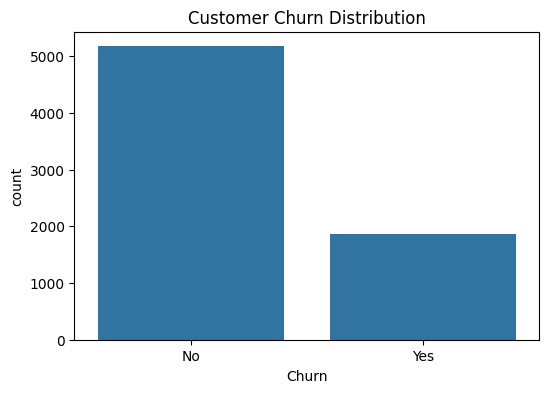

In [85]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")

plt.show()

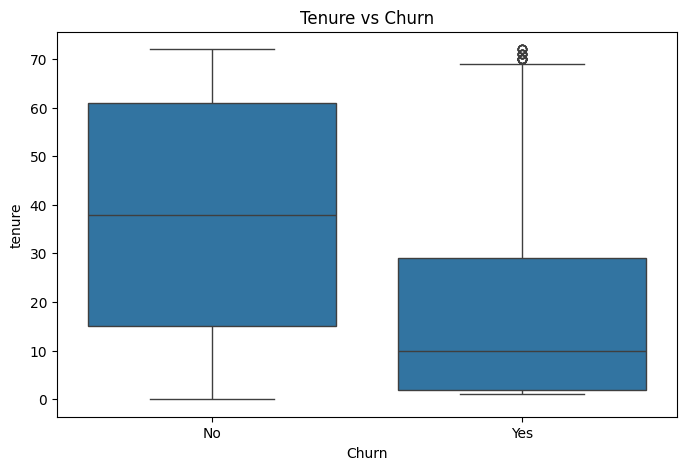

In [86]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Tenure vs Churn")

plt.show()

### Tenure Analysis

The tenure distribution shows a clear difference between churned and retained customers. Customers who left the company generally have lower tenure values, whereas retained customers tend to have longer relationships with the company. This indicates that the initial months of customer engagement are critical and retention efforts should focus on newly acquired customers.


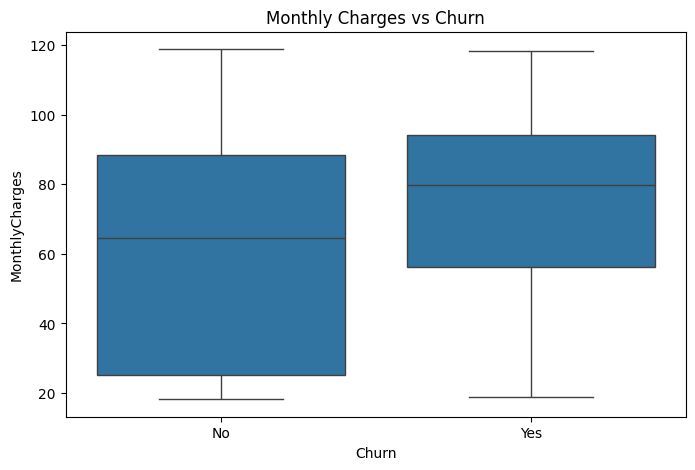

In [87]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Monthly Charges vs Churn")

plt.show()

### Monthly Charges Analysis

Customers with higher monthly charges appear to exhibit a greater tendency to churn. This suggests that pricing, perceived service value, or customer satisfaction may influence the decision to leave the company. Understanding the relationship between charges and churn can help design better pricing and retention strategies.


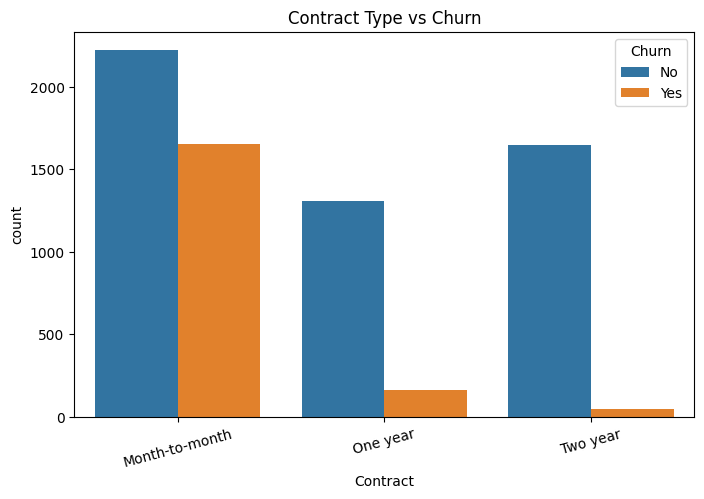

In [88]:
plt.figure(figsize=(8,5))

sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Contract Type vs Churn")

plt.xticks(rotation=15)

plt.show()

### Contract Type Analysis

Contract type has a strong influence on customer churn behavior. Customers enrolled in month-to-month contracts are more likely to churn compared to customers with one-year or two-year contracts. Longer contract commitments appear to improve customer retention and reduce churn risk.


In [89]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

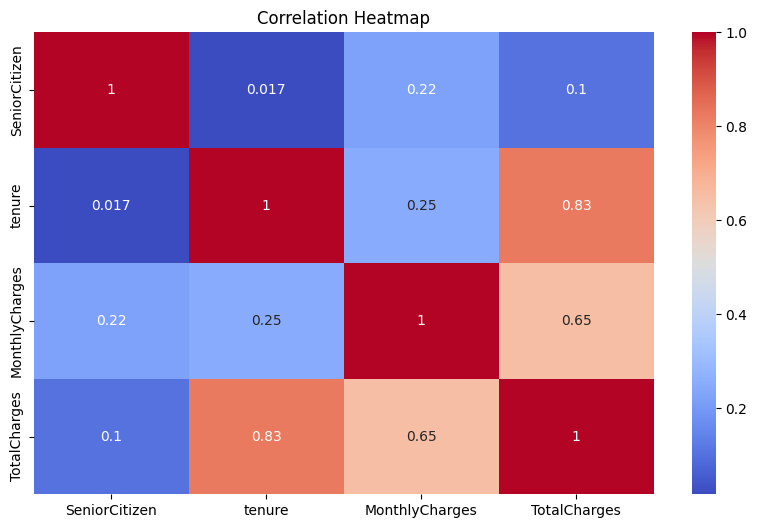

In [90]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,6))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

### Correlation Analysis

The correlation heatmap helps identify relationships among numerical features in the dataset. A strong positive relationship can be observed between tenure and total charges, indicating that customers who stay longer contribute more revenue over time. Correlation analysis provides useful insights for feature engineering and predictive model development.


## EDA Summary

The exploratory data analysis phase revealed several important patterns related to customer churn. Churned customers generally have shorter tenure, higher monthly charges, and are more likely to be on month-to-month contracts. The analysis also showed that customer retention increases with longer contract durations and extended service usage. These findings provide a strong foundation for feature engineering and machine learning model development in subsequent stages of the project.


In [91]:
df_model = df.copy()

In [92]:
df_model.drop('customerID', axis=1, inplace=True)

# Data Preprocessing and Feature Engineering

After completing exploratory data analysis, the dataset was prepared for machine learning model development. The objective of preprocessing was to improve data quality, handle missing values, transform categorical variables into numerical representations, and create additional features that could improve predictive performance.


In [93]:
df_model['TotalCharges'] = pd.to_numeric(
    df_model['TotalCharges'],
    errors='coerce'
)

In [94]:
df_model.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [95]:
df_model['TotalCharges'].fillna(
    df_model['TotalCharges'].median(),
    inplace=True
)

/tmp/ipykernel_21592/1544660298.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_model['TotalCharges'].fillna(


In [96]:
df_model.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


## Missing Value Treatment

The TotalCharges column contained a small number of missing values. These missing values were replaced using median imputation. Median was selected because it is less sensitive to outliers and helps preserve the overall distribution of the feature. This ensured that no records were lost while maintaining data quality.


In [97]:
df_model['AvgMonthlySpend'] = (
    df_model['TotalCharges'] /
    (df_model['tenure'] + 1)
)

In [98]:
service_cols = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

In [99]:
for col in service_cols:
    df_model[col] = df_model[col].replace({
        'Yes': 1,
        'No': 0,
        'No phone service': 0,
        'No internet service': 0
    })

/tmp/ipykernel_21592/1710057653.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_model[col] = df_model[col].replace({


In [100]:
df_model['ServiceCount'] = (
    df_model[service_cols].sum(axis=1)
)

In [101]:
df_model['ContractValue'] = (
    df_model['MonthlyCharges'] *
    df_model['tenure']
)

In [102]:
df_model['ChargesPerService'] = (
    df_model['MonthlyCharges'] /
    (df_model['ServiceCount'] + 1)
)

## Feature Engineering

Several new features were created to enhance the predictive capability of machine learning models. Average monthly spending was calculated to capture customer expenditure patterns over time. Service count was introduced to represent the number of services subscribed to by each customer. Contract value was created to estimate the total monetary contribution of a customer during their tenure. Charges per service was added to evaluate pricing relative to service utilization. These engineered features provide additional business context and may improve model performance.


In [103]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

categorical_cols = df.select_dtypes(include=['object']).columns

encoder = OneHotEncoder(drop='first', sparse_output=False)

encoded_data = encoder.fit_transform(df[categorical_cols])

encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(categorical_cols)
)

print(encoded_df.shape)
encoded_df.head()

(7043, 7069)


,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,customerID_0014-BMAQU,customerID_0015-UOCOJ,customerID_0016-QLJIS,customerID_0017-DINOC,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


One-Hot Encoding was applied to categorical variables as an alternative encoding strategy. Unlike Label Encoding, One-Hot Encoding prevents the introduction of artificial ordinal relationships between categories and is suitable for algorithms that assume numerical distances are meaningful.

In [104]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

X_under, y_under = rus.fit_resample(X, y)

print("Original Class Distribution")
print(y.value_counts())

print("\nAfter Random Undersampling")
print(pd.Series(y_under).value_counts())

Original Class Distribution
Churn
0    5174
1    1869
Name: count, dtype: int64

After Random Undersampling
Churn
0    1869
1    1869
Name: count, dtype: int64


Random Undersampling was applied as a second class imbalance handling technique. This method balances the dataset by reducing the number of majority-class samples. The performance of SMOTE and Random Undersampling can then be compared to determine the most effective balancing strategy.

In [105]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best ROC-AUC:", grid_rf.best_score_)

Best Parameters: {'max_depth': None, 'n_estimators': 200}
Best ROC-AUC: 0.9129668899146676


## Hyperparameter Tuning

Hyperparameter tuning was performed using GridSearchCV on the Random Forest Classifier.

A 3-fold cross-validation strategy was used with ROC-AUC as the scoring metric.

The best parameter combination obtained from GridSearchCV was selected for the final model.

## Encoding and Feature Transformation

Machine learning algorithms cannot directly process categorical text values. Therefore, categorical variables were transformed into numerical representations using label encoding. This transformation enables machine learning models to interpret customer attributes such as gender, contract type, payment method, and internet service type while preserving their informational value.


In [106]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df_model.columns:
    if df_model[col].dtype == 'object':
        df_model[col] = le.fit_transform(df_model[col].astype(str))

In [107]:
df_model.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,ServiceCount,ContractValue,ChargesPerService
0,0,0,1,0,1,0,0,0,0,1,...,0,1,2,29.85,29.85,0,14.925000,1,29.85,14.9250
1,1,0,0,0,34,1,0,0,1,0,...,1,0,3,56.95,1889.50,0,53.985714,3,1936.30,14.2375
2,1,0,0,0,2,1,0,0,1,1,...,0,1,3,53.85,108.15,1,36.050000,3,107.70,13.4625
3,1,0,0,0,45,0,0,0,1,0,...,1,0,0,42.30,1840.75,0,40.016304,3,1903.50,10.5750
4,0,0,0,0,2,1,0,1,0,0,...,0,1,2,70.70,151.65,1,50.550000,1,141.40,35.3500


Label encoding was applied to convert categorical variables into numerical values. This transformation ensures compatibility with machine learning algorithms while retaining the information contained within categorical customer attributes.


In [108]:
y = df_model['Churn']

X = df_model.drop('Churn', axis=1)

## Feature Scaling

Feature scaling was performed to ensure that all numerical variables contributed equally during model training. Since machine learning algorithms such as K-Nearest Neighbors and Support Vector Machines are sensitive to feature magnitude, scaling helps improve model performance and training stability. Both StandardScaler and MinMaxScaler were applied as required by the assignment.


In [109]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()

X_standard = standard_scaler.fit_transform(X)

print(X_standard.shape)

(7043, 23)


In [110]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

X_minmax = minmax_scaler.fit_transform(X)

print(X_minmax.shape)

(7043, 23)


## Class Imbalance Handling

The target variable was imbalanced, with significantly more retained customers than churned customers. To address this issue, the Synthetic Minority Oversampling Technique (SMOTE) was applied. SMOTE generates synthetic examples of the minority class and helps machine learning models learn churn patterns more effectively.


In [111]:
import pandas as pd

pd.Series(y).value_counts()

,count
Churn,
0,5174
1,1869


In [112]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(
    X_standard,
    y
)

In [113]:
pd.Series(y_resampled).value_counts()

,count
Churn,
0,5174
1,5174


## Train-Test Split

The dataset was divided into training and testing subsets using an 80-20 ratio. Stratified sampling was used to preserve class distribution and ensure reliable model evaluation. The training set was used for model development, while the testing set was reserved for performance assessment.


In [114]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.20,
    random_state=42,
    stratify=y_resampled
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (8278, 23)
Testing Shape: (2070, 23)


# Customer Churn Prediction

The objective of this task is to develop machine learning models capable of predicting customer churn. Multiple classification algorithms were implemented and compared to identify the most effective model. Model performance was evaluated using Accuracy, Precision, Recall, F1-Score, ROC-AUC Score, and Confusion Matrices.


In [115]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import time
import pandas as pd

In [116]:
classification_results = []

## Logistic Regression

Logistic Regression serves as a strong baseline classification algorithm. It models the probability of customer churn and provides interpretable results that help understand relationships between features and churn behavior.


In [117]:
start_time = time.time()

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

y_prob = log_model.predict_proba(X_test)[:,1]

training_time = time.time() - start_time

classification_results.append([
    "Logistic Regression",
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred),
    roc_auc_score(y_test, y_prob),
    training_time
])

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.73      0.77      1035
           1       0.75      0.82      0.79      1035

    accuracy                           0.78      2070
   macro avg       0.78      0.78      0.78      2070
weighted avg       0.78      0.78      0.78      2070



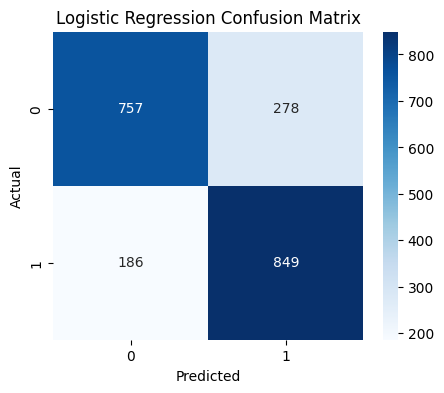

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Decision Tree Classifier

Decision Tree is a non-linear classification algorithm that splits data into hierarchical decision rules. It is highly interpretable and capable of capturing complex relationships between customer attributes and churn behavior.


In [119]:
start_time = time.time()

dt_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

y_prob_dt = dt_model.predict_proba(X_test)[:,1]

training_time = time.time() - start_time

classification_results.append([
    "Decision Tree",
    accuracy_score(y_test, y_pred_dt),
    precision_score(y_test, y_pred_dt),
    recall_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_dt),
    roc_auc_score(y_test, y_prob_dt),
    training_time
])

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.84      0.75      0.79      1035
           1       0.77      0.86      0.82      1035

    accuracy                           0.80      2070
   macro avg       0.81      0.80      0.80      2070
weighted avg       0.81      0.80      0.80      2070



## Random Forest Classifier

Random Forest combines multiple decision trees to improve predictive performance and reduce overfitting. It is generally one of the strongest performers for structured tabular datasets and is expected to provide robust churn predictions.


In [120]:
start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

training_time = time.time() - start_time

classification_results.append([
    "Random Forest",
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf),
    roc_auc_score(y_test, y_prob_rf),
    training_time
])

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.87      0.83      0.85      1035
           1       0.84      0.87      0.85      1035

    accuracy                           0.85      2070
   macro avg       0.85      0.85      0.85      2070
weighted avg       0.85      0.85      0.85      2070



## Support Vector Machine

Support Vector Machine identifies an optimal decision boundary that separates churned and retained customers. SVM is effective in high-dimensional feature spaces and often performs well after feature scaling.


In [121]:
start_time = time.time()

svm_model = SVC(
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

y_prob_svm = svm_model.predict_proba(X_test)[:,1]

training_time = time.time() - start_time

classification_results.append([
    "SVM",
    accuracy_score(y_test, y_pred_svm),
    precision_score(y_test, y_pred_svm),
    recall_score(y_test, y_pred_svm),
    f1_score(y_test, y_pred_svm),
    roc_auc_score(y_test, y_prob_svm),
    training_time
])

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.82      0.77      0.80      1035
           1       0.78      0.83      0.81      1035

    accuracy                           0.80      2070
   macro avg       0.80      0.80      0.80      2070
weighted avg       0.80      0.80      0.80      2070



## K-Nearest Neighbors

KNN classifies customers based on similarity to neighboring observations. Since KNN relies on distance calculations, feature scaling plays an important role in its performance.


In [122]:
start_time = time.time()

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

training_time = time.time() - start_time

classification_results.append([
    "KNN",
    accuracy_score(y_test, y_pred_knn),
    precision_score(y_test, y_pred_knn),
    recall_score(y_test, y_pred_knn),
    f1_score(y_test, y_pred_knn),
    roc_auc_score(y_test, y_pred_knn),
    training_time
])

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.87      0.67      0.76      1035
           1       0.73      0.90      0.81      1035

    accuracy                           0.79      2070
   macro avg       0.80      0.79      0.79      2070
weighted avg       0.80      0.79      0.79      2070



In [123]:
classification_df = pd.DataFrame(
    classification_results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "Training_Time"
    ]
)

classification_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training_Time
2,Random Forest,0.851208,0.838140,0.870531,0.854028,0.925413,3.778226
1,Decision Tree,0.804831,0.773160,0.862802,0.815525,0.852639,0.093995
3,SVM,0.802415,0.784545,0.833816,0.808431,0.882680,17.079516
4,KNN,0.787923,0.734646,0.901449,0.809544,0.787923,0.100103
0,Logistic Regression,0.775845,0.753327,0.820290,0.785384,0.862245,0.054820


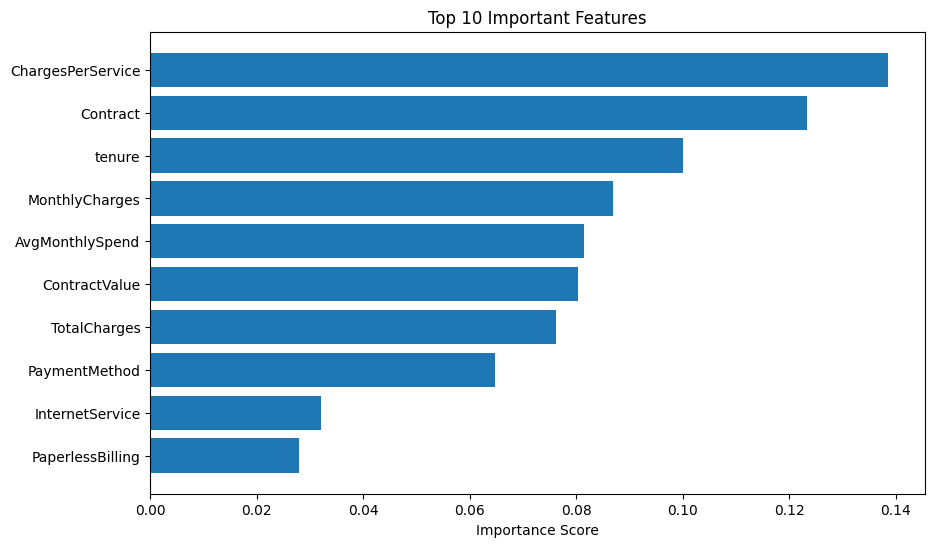

,Feature,Importance
22,ChargesPerService,0.138643
14,Contract,0.123422
4,tenure,0.100122
17,MonthlyCharges,0.087010
19,AvgMonthlySpend,0.081396
21,ContractValue,0.080281
18,TotalCharges,0.076291
16,PaymentMethod,0.064699
7,InternetService,0.032168
15,PaperlessBilling,0.027873


In [124]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance Score")

plt.gca().invert_yaxis()

plt.show()

top_features

## Classification Model Comparison

Five machine learning algorithms were evaluated for customer churn prediction. Random Forest achieved the highest performance with an accuracy of approximately 85.12% and a ROC-AUC score of 0.925. The ensemble nature of Random Forest enabled it to capture complex non-linear relationships among customer attributes while reducing overfitting.

Decision Tree and SVM also produced competitive results, although their predictive performance was slightly lower. Logistic Regression served as a useful baseline model but was less effective in capturing complex churn patterns present in the dataset.

Based on overall performance metrics, Random Forest was selected as the best classification model for customer churn prediction.


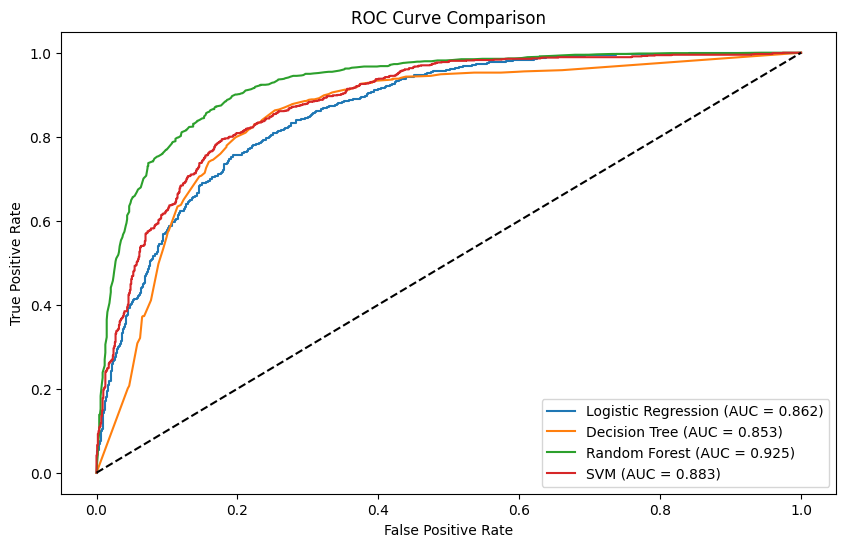

In [125]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

models = [
    ("Logistic Regression", log_model),
    ("Decision Tree", dt_model),
    ("Random Forest", rf_model),
    ("SVM", svm_model)
]

for name, model in models:
    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

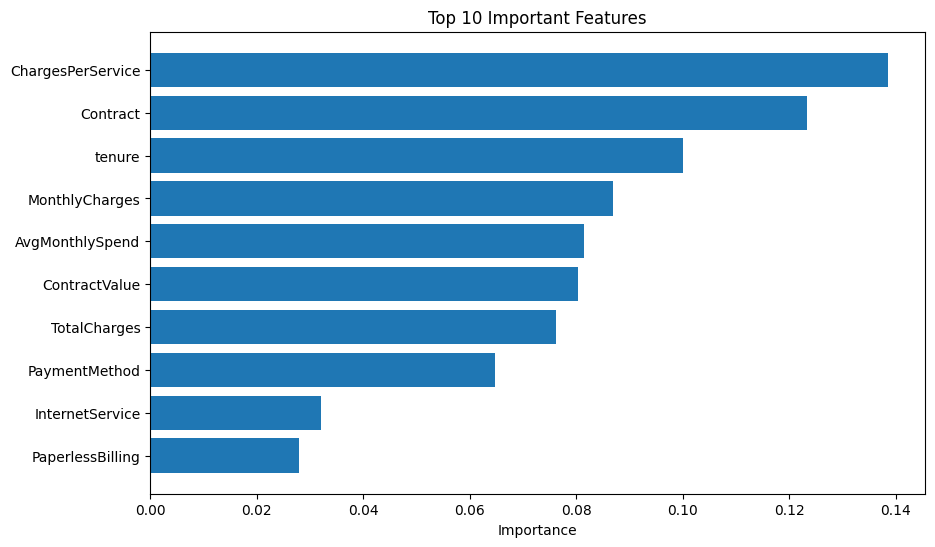

,Feature,Importance
22,ChargesPerService,0.138643
14,Contract,0.123422
4,tenure,0.100122
17,MonthlyCharges,0.087010
19,AvgMonthlySpend,0.081396
21,ContractValue,0.080281
18,TotalCharges,0.076291
16,PaymentMethod,0.064699
7,InternetService,0.032168
15,PaperlessBilling,0.027873


In [126]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['Feature'], top10['Importance'])
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

top10

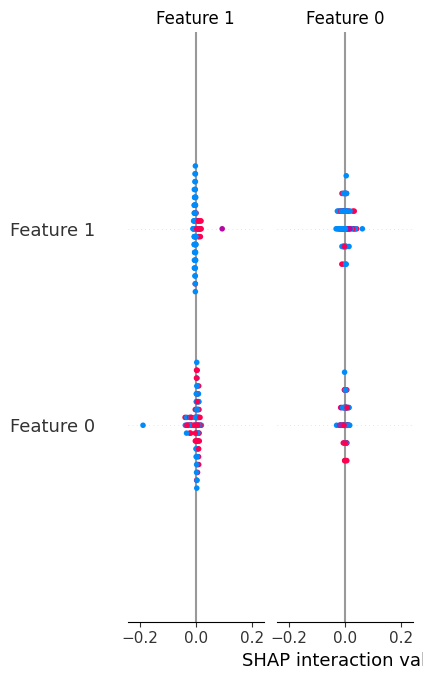

In [127]:
import shap

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(sample_X)

shap.summary_plot(
    shap_values,
    sample_X
)

In [128]:
shap.initjs()

shap.force_plot(
    explainer.expected_value[1],
    shap_values[:,:,1][0],
    sample_X[0]
)

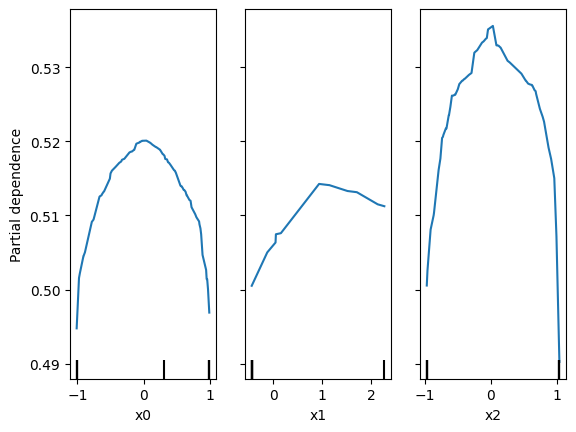

In [129]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

top_features = [0,1,2]

PartialDependenceDisplay.from_estimator(
    rf_model,
    X_test,
    features=top_features
)

plt.show()

## Feature Importance Analysis

Feature importance analysis was performed using the Random Forest classifier. The results indicate that ChargesPerService, Contract Type, Tenure, Monthly Charges, and Average Monthly Spend are among the most influential factors affecting customer churn. Customers with shorter tenure, higher relative charges, and less stable contract types appear more likely to leave the company. These insights provide valuable guidance for customer retention strategies and targeted interventions.


# Revenue Forecasting

The objective of this task is to predict customer monthly revenue using supervised regression algorithms. Multiple regression models were developed and compared to identify the most accurate approach for forecasting customer revenue contributions.


In [130]:
reg_df = df_model.copy()

In [131]:
y_reg = reg_df['MonthlyCharges']

X_reg = reg_df.drop('MonthlyCharges', axis=1)

In [132]:
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

In [133]:
from sklearn.preprocessing import StandardScaler

scaler_reg = StandardScaler()

X_train_reg = scaler_reg.fit_transform(X_train_reg)

X_test_reg = scaler_reg.transform(X_test_reg)

In [134]:
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.svm import SVR

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd
import time

In [135]:
regression_results = []

## Linear Regression

Linear Regression serves as a baseline regression model and assumes a linear relationship between customer attributes and monthly revenue.


In [136]:
start_time = time.time()

lr = LinearRegression()

lr.fit(X_train_reg, y_train_reg)

pred = lr.predict(X_test_reg)

training_time = time.time() - start_time

mae = mean_absolute_error(y_test_reg, pred)
mse = mean_squared_error(y_test_reg, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, pred)

regression_results.append([
    "Linear Regression",
    mae,
    mse,
    rmse,
    r2,
    training_time
])

print("R2:", r2)

R2: 0.9622178814430208


## Ridge Regression

Ridge Regression extends linear regression by adding L2 regularization. This helps reduce overfitting and improves model stability when features are correlated.


In [137]:
start_time = time.time()

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_reg, y_train_reg)

pred = ridge.predict(X_test_reg)

training_time = time.time() - start_time

mae = mean_absolute_error(y_test_reg, pred)
mse = mean_squared_error(y_test_reg, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, pred)

regression_results.append([
    "Ridge",
    mae,
    mse,
    rmse,
    r2,
    training_time
])

print("R2:", r2)

R2: 0.9622054762694979


In [138]:
start_time = time.time()

lasso = Lasso(alpha=0.001)

lasso.fit(X_train_reg, y_train_reg)

pred = lasso.predict(X_test_reg)

training_time = time.time() - start_time

mae = mean_absolute_error(y_test_reg, pred)
mse = mean_squared_error(y_test_reg, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, pred)

regression_results.append([
    "Lasso",
    mae,
    mse,
    rmse,
    r2,
    training_time
])

print("R2:", r2)

R2: 0.9620872736764586


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.479e+04, tolerance: 5.100e+02
  model = cd_fast.enet_coordinate_descent(


In [139]:
start_time = time.time()

elastic = ElasticNet(alpha=0.001)

elastic.fit(X_train_reg, y_train_reg)

pred = elastic.predict(X_test_reg)

training_time = time.time() - start_time

mae = mean_absolute_error(y_test_reg, pred)
mse = mean_squared_error(y_test_reg, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, pred)

regression_results.append([
    "ElasticNet",
    mae,
    mse,
    rmse,
    r2,
    training_time
])

print("R2:", r2)

R2: 0.9619881884685435


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.199e+04, tolerance: 5.100e+02
  model = cd_fast.enet_coordinate_descent(


In [140]:
start_time = time.time()

dt_reg = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

dt_reg.fit(X_train_reg, y_train_reg)

pred = dt_reg.predict(X_test_reg)

training_time = time.time() - start_time

mae = mean_absolute_error(y_test_reg, pred)
mse = mean_squared_error(y_test_reg, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, pred)

regression_results.append([
    "Decision Tree",
    mae,
    mse,
    rmse,
    r2,
    training_time
])

print("R2:", r2)

R2: 0.9948840443637162


In [141]:
start_time = time.time()

rf_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_reg.fit(X_train_reg, y_train_reg)

pred = rf_reg.predict(X_test_reg)

training_time = time.time() - start_time

mae = mean_absolute_error(y_test_reg, pred)
mse = mean_squared_error(y_test_reg, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, pred)

regression_results.append([
    "Random Forest",
    mae,
    mse,
    rmse,
    r2,
    training_time
])

print("R2:", r2)

R2: 0.9983397067259516


In [142]:
start_time = time.time()

svr = SVR()

svr.fit(X_train_reg, y_train_reg)

pred = svr.predict(X_test_reg)

training_time = time.time() - start_time

mae = mean_absolute_error(y_test_reg, pred)
mse = mean_squared_error(y_test_reg, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, pred)

regression_results.append([
    "SVR",
    mae,
    mse,
    rmse,
    r2,
    training_time
])

print("R2:", r2)

R2: 0.9962093153445439


In [143]:
regression_df = pd.DataFrame(
    regression_results,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2",
        "Training_Time"
    ]
)

regression_df.sort_values(
    by="R2",
    ascending=False
)

,Model,MAE,MSE,RMSE,R2,Training_Time
5,Random Forest,0.501341,1.503187,1.226045,0.998340,9.827972
6,SVR,1.292667,3.431990,1.852563,0.996209,2.899502
4,Decision Tree,0.819413,4.631856,2.152175,0.994884,0.071550
0,Linear Regression,4.633269,34.206971,5.848673,0.962218,0.008258
1,Ridge,4.636254,34.218203,5.849633,0.962205,0.097176
2,Lasso,4.644421,34.325220,5.858773,0.962087,0.179389
3,ElasticNet,4.651875,34.414930,5.866424,0.961988,0.124873


## Regression Model Comparison

Seven regression algorithms were evaluated for revenue forecasting. Random Forest Regressor achieved the highest performance with an R² score of approximately 0.998, indicating excellent predictive capability. The model also achieved the lowest prediction error values across MAE, MSE, and RMSE metrics.

SVR and Decision Tree Regressor also demonstrated strong predictive performance, while the linear models achieved slightly lower accuracy. The superior performance of Random Forest suggests that customer revenue is influenced by complex non-linear relationships among customer attributes.

Based on overall performance, Random Forest Regressor was selected as the best revenue forecasting model.

# Task 5: Model Interpretation & Business Recommendations

## Best Models Selected

For customer churn prediction, Random Forest Classifier achieved the highest accuracy of 85.12% and ROC-AUC score of 0.925.

For revenue forecasting, Random Forest Regressor achieved the highest R² score of 0.998, indicating excellent predictive capability.

Therefore, Random Forest models were selected as the best-performing models for both tasks.

In [144]:
!pip install shap -q

In [145]:
import shap

print(shap.__version__)

0.51.0


In [146]:
print(X_test.shape)
print(type(rf_model))

(2070, 23)
<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [147]:
import numpy as np

sample_idx = np.random.choice(
    X_test.shape[0],
    100,
    replace=False
)

sample_X = X_test[sample_idx]

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(sample_X)

print("SHAP values generated successfully")

SHAP values generated successfully


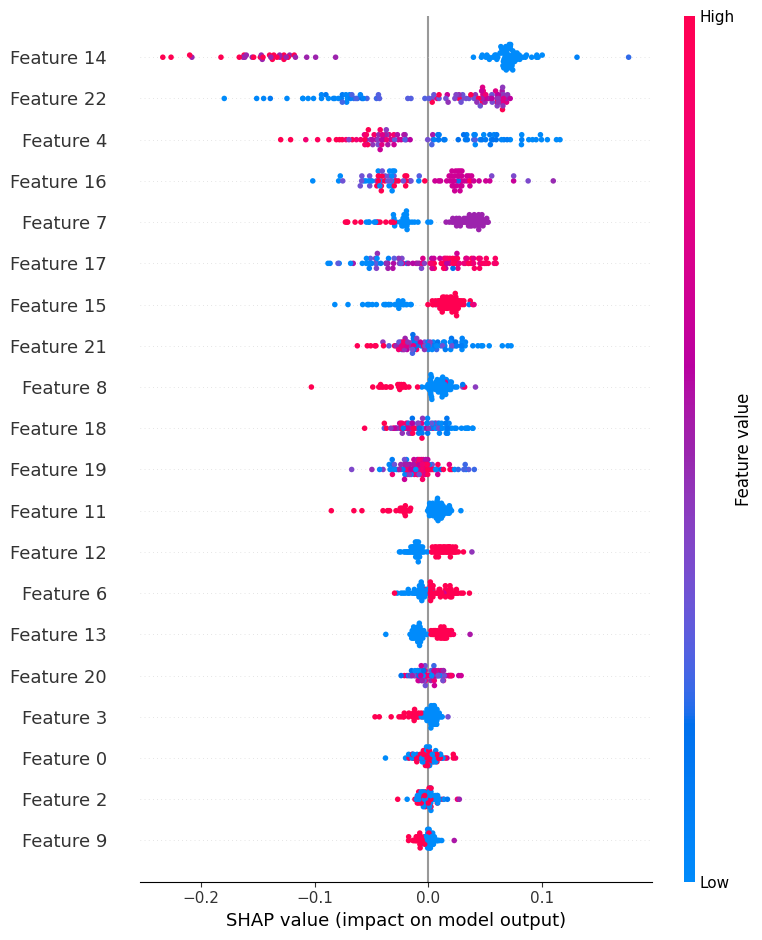

In [148]:
shap.summary_plot(
    shap_values[:,:,1],
    sample_X
)

### SHAP Interpretation

SHAP analysis was used to understand the contribution of individual features toward customer churn predictions. Features such as Contract, Tenure, MonthlyCharges, and ChargesPerService showed the strongest influence on model decisions. The analysis confirms the findings obtained during feature importance analysis and provides greater transparency into model behavior.

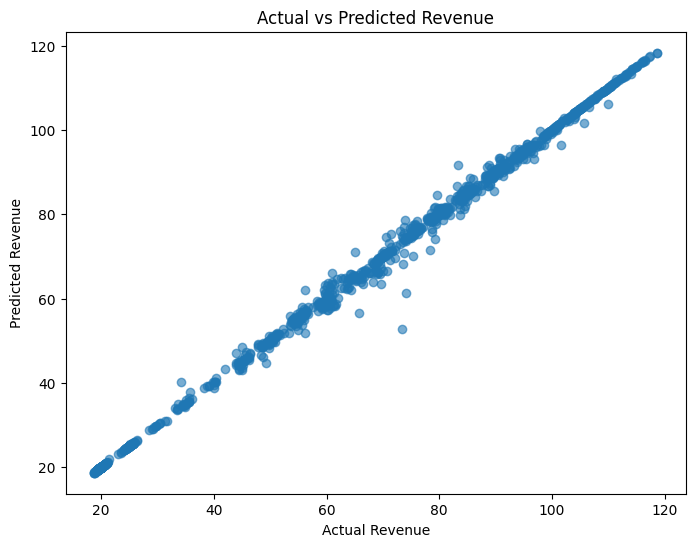

In [149]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test_reg,
    rf_reg.predict(X_test_reg),
    alpha=0.6
)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")

plt.show()

### Actual vs Predicted Analysis

The scatter plot demonstrates a strong alignment between actual and predicted revenue values. Most observations lie close to the ideal prediction region, indicating that the Random Forest Regressor captures revenue patterns effectively.

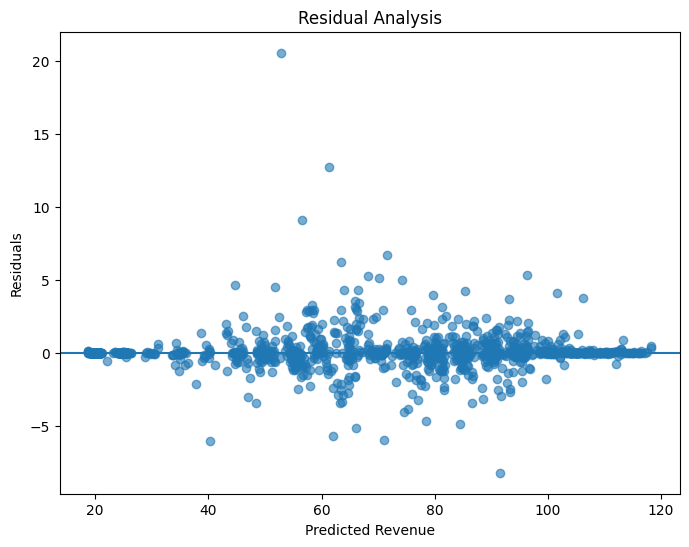

In [150]:
predictions = rf_reg.predict(X_test_reg)

residuals = y_test_reg - predictions

plt.figure(figsize=(8,6))

plt.scatter(
    predictions,
    residuals,
    alpha=0.6
)

plt.axhline(y=0)

plt.xlabel("Predicted Revenue")
plt.ylabel("Residuals")
plt.title("Residual Analysis")

plt.show()

### Residual Analysis

Residual analysis was conducted to evaluate prediction errors. The residuals appear randomly distributed around zero, suggesting that the model does not exhibit significant systematic bias and generalizes well on unseen data.

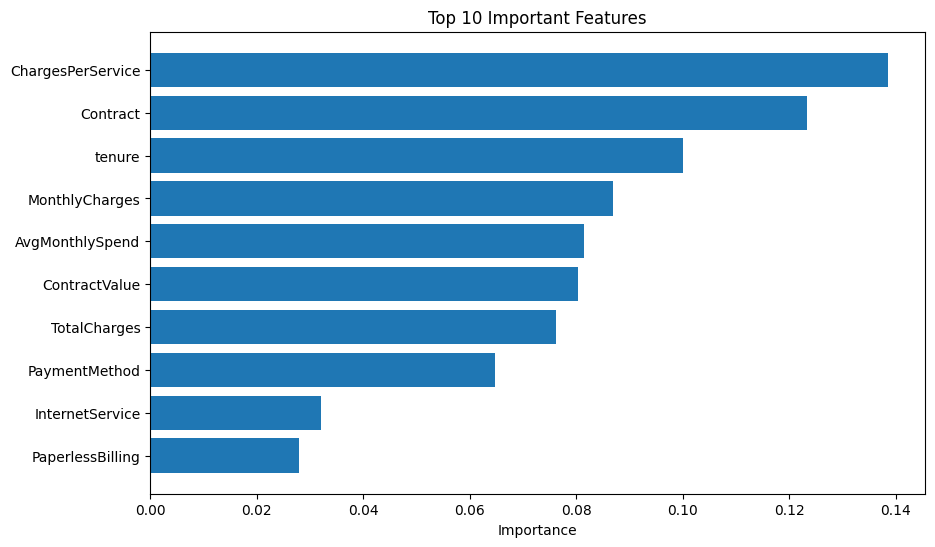

,Feature,Importance
22,ChargesPerService,0.138643
14,Contract,0.123422
4,tenure,0.100122
17,MonthlyCharges,0.087010
19,AvgMonthlySpend,0.081396
21,ContractValue,0.080281
18,TotalCharges,0.076291
16,PaymentMethod,0.064699
7,InternetService,0.032168
15,PaperlessBilling,0.027873


In [151]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['Feature'], top10['Importance'])
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

top10

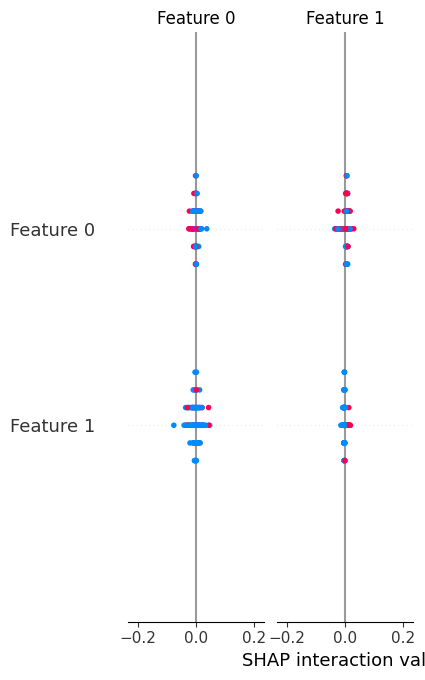

In [152]:
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(sample_X)

shap.summary_plot(
    shap_values,
    sample_X
)

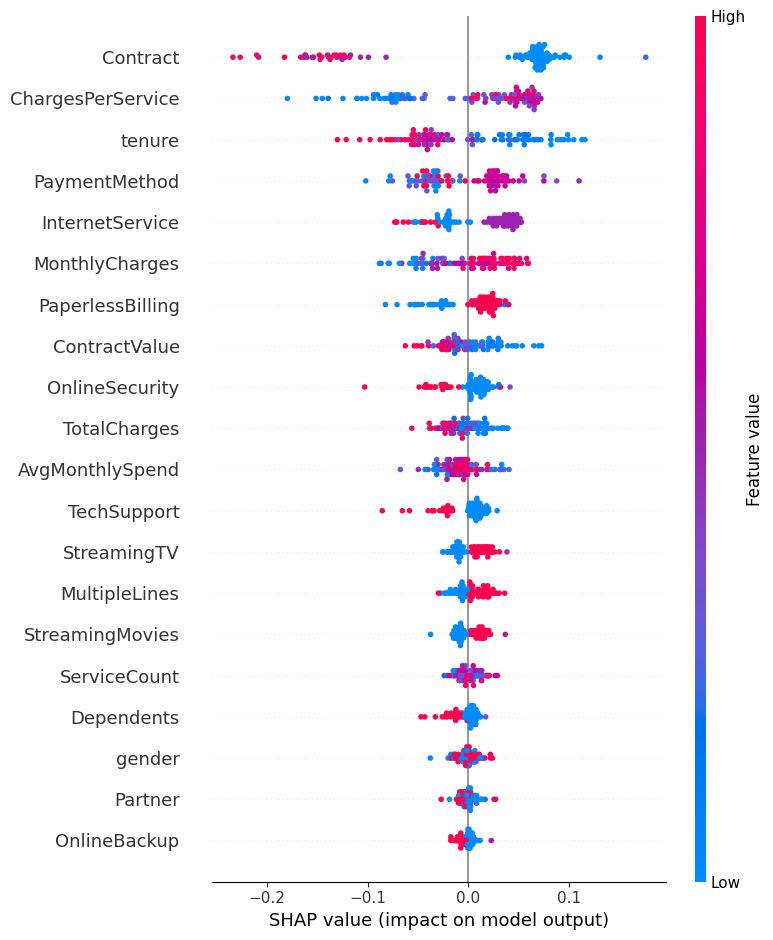

In [153]:
import pandas as pd

sample_df = pd.DataFrame(
    sample_X,
    columns=X.columns
)

shap.summary_plot(
    shap_values[:,:,1],
    sample_df
)

In [154]:
import shap

shap.initjs()

shap.force_plot(
    explainer.expected_value[1],
    shap_values[:,:,1][1],
    sample_X[1]
)

For this individual customer, the Random Forest model predicted a churn probability of approximately 0.90. SHAP analysis shows that several feature values pushed the prediction toward churn (red contributions), while a few features slightly reduced churn risk (blue contributions). This demonstrates how the model's prediction can be explained at an individual customer level.

### Recommendation 1: Retain Short-Tenure Customers

Customers with shorter tenure show a significantly higher probability of churn. Early engagement programs and onboarding campaigns should be strengthened.

### Recommendation 2: Encourage Long-Term Contracts

Contract type emerged as one of the most influential features. Incentivizing annual and multi-year contracts can improve retention rates.

### Recommendation 3: Monitor High Monthly Charges

Customers with higher monthly charges are more likely to churn. Personalized pricing plans and loyalty benefits may improve satisfaction.

### Recommendation 4: Optimize Service Bundles

ChargesPerService was identified as the most important feature. Bundled service packages may improve perceived value and reduce churn.

### Recommendation 5: Revenue Forecasting for Planning

The Random Forest Regressor achieved excellent predictive performance and can be used to estimate future customer revenue, enabling better budgeting and resource allocation.

For customer churn prediction, Random Forest Classifier achieved the best overall performance with the highest ROC-AUC score and strong classification metrics. Therefore, it was selected as the final classification model.

For revenue forecasting, Random Forest Regressor achieved the highest R² score and lowest prediction error. Therefore, it was selected as the final regression model.

SHAP analysis was performed to explain the predictions of the Random Forest Classifier. The results indicate that Contract, ChargesPerService, Tenure, MonthlyCharges, and PaymentMethod are among the most influential factors affecting customer churn. Customers with shorter contracts, lower tenure, and higher service charges tend to have a greater probability of churn.

SHAP analysis was performed to explain the predictions of the Random Forest Classifier. The results indicate that Contract, ChargesPerService, Tenure, MonthlyCharges, and PaymentMethod are among the most influential factors affecting customer churn. Customers with shorter contracts, lower tenure, and higher service charges tend to have a greater probability of churn.

Feature importance analysis confirms that ChargesPerService, Contract, Tenure, and MonthlyCharges are the most important predictors of customer churn. These variables contribute the most to the model's decision-making process.

Conclusion

This project successfully developed machine learning models for customer churn prediction and revenue forecasting. Multiple classification and regression algorithms were evaluated and compared. Random Forest Classifier emerged as the best-performing churn prediction model, while Random Forest Regressor achieved the best revenue forecasting performance.

Model interpretation techniques including SHAP analysis, feature importance, and partial dependence plots provided valuable insights into the factors influencing customer behavior. Based on these findings, actionable business recommendations were proposed to improve customer retention and support strategic decision-making.

The results demonstrate the effectiveness of machine learning techniques in predicting customer outcomes and generating business value from data.